In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

im = np.array(Image.open(filename).convert("L"))

Saving shells.tif to shells.tif


In [7]:
def histogram_equalization(im):

    histogram = np.zeros(256, dtype=int)

    # Calculate Histogram
    for pixel in im.ravel():
        histogram[pixel] += 1

    # Calculate Cumulative Histogram
    cdf = np.cumsum(histogram)


    # Find first non-zero CDF value
    cdf_min = cdf[cdf > 0][0]

    N = im.size


    # Construct transformation
    transformation = np.round(
        255 * (cdf - cdf_min) / (N - cdf_min)
    )

    transformation = np.clip(
        transformation,
        0,
        255
    ).astype(np.uint8)


    # Apply transformation
    equalized_im = transformation[im]

    return equalized_im

In [8]:
equalized_im = histogram_equalization(im)

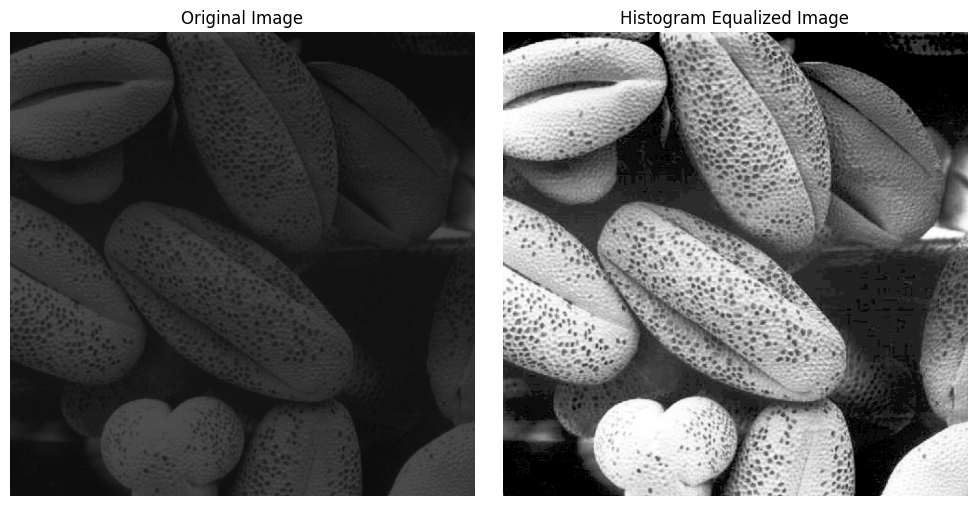

In [9]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized_im, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

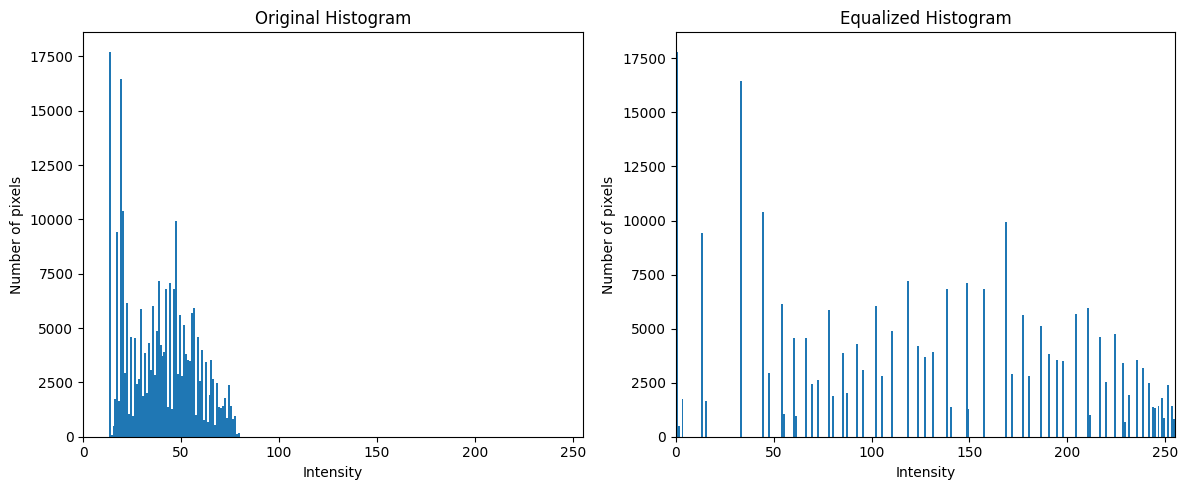

In [10]:
plt.figure(figsize=(12, 5))

# Original histogram
plt.subplot(1, 2, 1)

plt.hist(
    im.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlim(0, 255)
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Original Histogram")


# Equalized histogram
plt.subplot(1, 2, 2)

plt.hist(
    equalized_im.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlim(0, 255)
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()